# Schema Interconnectivity and Mapping Coverage in the Life-Sciences Linked Open Data Cloud

This notebook quantifies the structural properties of the mined schema graph and assesses how curated and inferred mappings extend cross-dataset connectivity.  

**Scope.** 
- instance-based matching
- curated SeMRA imports
- curated OLS SSSOM imports
- inference-expanded mappings 

Then measuring how each layer changes the inter-dataset reachability structure.

Three graph variants are constructed:

* **G_schema** - typed-object edges extracted from mined schemas only (no mappings).
* **G_raw** - G_schema augmented with non-inferenced mapping edges (instance + semra + sssom).
* **G_inferred** - G_raw augmented with the inferenced mapping layer.

Domain annotations from `sources.yaml` (bioregistry keywords) are used to colour nodes
by scientific domain and characterise the cross-domain connectivity of the LSLOD cloud.

## 1. Setup

In [4]:
from __future__ import annotations

import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

# ── paths ────────────────────────────────────────────────────────────────────
ROOT = Path("..").resolve()          # repo root when notebook is in notebooks/
OUTPUT_DIR       = ROOT.parent / "output"   # /home/.../rdfsolve/output
MAPPINGS_DIR     = OUTPUT_DIR / "mappings"
MAPPINGS_SSSOM   = MAPPINGS_DIR / "sssom"
MAPPINGS_SEMRA   = MAPPINGS_DIR / "semra"
MAPPINGS_INST    = MAPPINGS_DIR / "instance_matching"
MAPPINGS_INF     = MAPPINGS_DIR / "inferenced"

# Schemas are scattered throughout output/ (not in a single subdir).
# We collect all *_schema.jsonld recursively.
SCHEMA_JSONLDS   = sorted(OUTPUT_DIR.rglob("*_schema.jsonld"))

# ── Load domain annotations from sources.yaml ────────────────────────────────
SOURCES_YAML = ROOT / "data" / "sources.yaml"
_sources_data = yaml.safe_load(SOURCES_YAML.read_text())
SOURCE_KEYWORDS: dict[str, list[str]] = {
    e["name"]: e.get("bioregistry_keywords", []) for e in _sources_data
}

# ── matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_palette("muted")

print(f"Output dir: {OUTPUT_DIR}")
print(f"Schema files found: {len(SCHEMA_JSONLDS)}")
print(f"Mapping dirs: sssom={MAPPINGS_SSSOM.exists()}, semra={MAPPINGS_SEMRA.exists()}, "
      f"inst={MAPPINGS_INST.exists()}, inf={MAPPINGS_INF.exists()}")
print(f"Sources with keywords: {sum(1 for v in SOURCE_KEYWORDS.values() if v)}/{len(SOURCE_KEYWORDS)}")
print("Environment ready.")

Output dir: /trinity/home/p70085013/rdfsolve/output
Schema files found: 320
Mapping dirs: sssom=True, semra=True, inst=True, inf=False
Sources with keywords: 229/231
Environment ready.


## 2. Artefact inventory

In [5]:
def _count_patterns(files: list[Path]) -> dict:
    """Return (n_files, n_non_empty, total_pattern_count) for a list of jsonld files."""
    n_non_empty = 0
    total = 0
    for f in files:
        about = json.loads(f.read_text()).get("@about", {})
        pc = about.get("pattern_count", 0) or 0
        total += pc
        if pc > 0:
            n_non_empty += 1
    return {"files": len(files), "non_empty": n_non_empty, "patterns": total}


inventory_rows = []
for label, files in [
    ("schemas",           SCHEMA_JSONLDS),
    ("sssom",             sorted(MAPPINGS_SSSOM.glob("*.jsonld")) if MAPPINGS_SSSOM.exists() else []),
    ("semra",             sorted(MAPPINGS_SEMRA.glob("*.jsonld")) if MAPPINGS_SEMRA.exists() else []),
    ("instance_matching", sorted(MAPPINGS_INST.glob("*.jsonld"))  if MAPPINGS_INST.exists()  else []),
    ("inferenced",        sorted(MAPPINGS_INF.glob("*.jsonld"))   if MAPPINGS_INF.exists()   else []),
]:
    stats = _count_patterns(files)
    inventory_rows.append({"layer": label, **stats})

df_inv = pd.DataFrame(inventory_rows).set_index("layer")
print(df_inv.to_string())
df_inv

                   files  non_empty  patterns
layer                                        
schemas              320        162   5234555
sssom                  0          0         0
semra                221        212  39650161
instance_matching      0          0         0
inferenced             0          0         0


,files,non_empty,patterns
layer,,,
schemas,320,162,5234555
sssom,0,0,0
semra,221,212,39650161
instance_matching,0,0,0
inferenced,0,0,0


## 3. Loading utilities

Schema and mapping JSON-LD files are loaded via `MinedSchema.from_jsonld()` and
`Mapping.from_jsonld()` - the canonical rdfsolve methods that correctly expand all
CURIEs from each file's own `@context` block and reconstruct typed Pydantic objects.
Each class also provides `to_networkx()` which returns an `nx.MultiDiGraph` directly.

In [6]:
from rdfsolve.models import MinedSchema, Mapping

def _shorten(uri: str) -> str:
    """Return a compact label for a URI (last path/fragment segment)."""
    for sep in ("#", "/"):
        idx = uri.rfind(sep)
        if idx >= 0 and idx < len(uri) - 1:
            return uri[idx + 1:]
    return uri

print("rdfsolve.models imported - MinedSchema.from_jsonld / Mapping.from_jsonld available.")

rdfsolve.models imported - MinedSchema.from_jsonld / Mapping.from_jsonld available.


## 4. Load all schema edges

In [7]:
print(f"Schema files found: {len(SCHEMA_JSONLDS)}")

schemas: list[MinedSchema] = []
for sf in SCHEMA_JSONLDS:
    try:
        ms = MinedSchema.from_jsonld(sf)
        schemas.append(ms)
    except Exception as exc:
        print(f"  WARNING: could not load {sf.name}: {exc}")

# Flatten to a DataFrame for analysis
schema_rows = []
for ms in schemas:
    ds = ms.about.dataset_name or ""
    for pat in ms.patterns:
        schema_rows.append({
            "dataset":       ds,
            "source_class":  pat.subject_class,
            "predicate":     pat.property_uri,
            "target_class":  pat.object_class,
            "count":         pat.count,
            "is_literal":    pat.object_class == "Literal",
            "is_resource":   pat.object_class == "Resource",
        })

df_schema = pd.DataFrame(schema_rows)
df_sch = df_schema[~df_schema["is_literal"] & ~df_schema["is_resource"]].copy()

print(f"Schemas loaded: {len(schemas)}")
print(f"Total patterns (all types): {len(df_schema):,}")
print(f"Typed-object patterns only: {len(df_sch):,}")
print(f"Unique datasets:             {df_sch['dataset'].nunique()}")
print(f"Unique source classes:       {df_sch['source_class'].nunique():,}")

# Quick sanity check: show pattern counts per dataset (top 10)
schema_stats = (
    df_sch.groupby("dataset")
    .agg(patterns=("source_class", "count"), classes=("source_class", "nunique"))
    .sort_values("patterns", ascending=False)
)
print("\nTop 10 datasets by typed-object pattern count:")
print(schema_stats.head(10).to_string())

Schema files found: 320
generated_by
  Field required [type=missing, input_value={'generatedBy': 'rdfsolve...ix', 'tripleCount': 882}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
generated_at
  Field required [type=missing, input_value={'generatedBy': 'rdfsolve...ix', 'tripleCount': 882}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
generated_by
  Field required [type=missing, input_value={'generatedBy': 'rdfsolve...po', 'tripleCount': 882}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
generated_at
  Field required [type=missing, input_value={'generatedBy': 'rdfsolve...po', 'tripleCount': 882}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
generated_by
  Field required [type=missing, input_value={'generatedBy': 'rdfsolve...ee', 'tripleCount': 641}, input_type=dict]
    For further information 

## 5. Load mapping edges -> build G_raw and G_inferred


In [8]:
import time
from collections import defaultdict

def _safe_glob(directory: Path, pattern: str = "*.jsonld") -> list[Path]:
    """Return sorted glob results, empty list if directory doesn't exist."""
    return sorted(directory.glob(pattern)) if directory.exists() else []

# ── G_schema ──────────────────────────────────────────────────────────────────
# Nodes = datasets.  Edges = at least one schema pattern whose object_class URI
# is also a subject_class in another dataset (typed-object cross-dataset links).
G_schema = nx.Graph()
for ms in schemas:
    ds = ms.about.dataset_name or ""
    G_schema.add_node(ds, pattern_count=len(ms.patterns))

class_to_datasets: dict[str, set[str]] = defaultdict(set)
for ms in schemas:
    ds = ms.about.dataset_name or ""
    for pat in ms.patterns:
        if pat.subject_class not in ("Literal", "Resource"):
            class_to_datasets[pat.subject_class].add(ds)

known_classes: set[str] = set(class_to_datasets.keys())

for ms in schemas:
    ds_src = ms.about.dataset_name or ""
    for pat in ms.patterns:
        if pat.object_class in ("Literal", "Resource"):
            continue
        for ds_tgt in class_to_datasets.get(pat.object_class, ()):
            if ds_tgt == ds_src:
                continue
            if G_schema.has_edge(ds_src, ds_tgt):
                G_schema[ds_src][ds_tgt]["weight"] += 1
            else:
                G_schema.add_edge(ds_src, ds_tgt, weight=1)

print(f"G_schema - nodes: {G_schema.number_of_nodes():3d}  edges: {G_schema.number_of_edges():5d}")
print(f"  known class URIs in schema: {len(known_classes):,}")

# ── G_raw via Mapping.dataset_graph() ────────────────────────────────────────
t0 = time.perf_counter()
raw_mapping_files = (
    _safe_glob(MAPPINGS_SSSOM)
    + _safe_glob(MAPPINGS_SEMRA)
    + _safe_glob(MAPPINGS_INST)
)
G_raw = Mapping.dataset_graph(
    paths=raw_mapping_files,
    class_to_datasets=class_to_datasets,
    base_graph=G_schema.copy(),
    strategies={"sssom_import", "semra_import", "instance_matcher"},
)
t_raw = time.perf_counter() - t0

new_raw = (set(frozenset(e) for e in G_raw.edges())
         - set(frozenset(e) for e in G_schema.edges()))
print(f"\nG_raw    - nodes: {G_raw.number_of_nodes():3d}  edges: {G_raw.number_of_edges():5d}"
      f"  ({t_raw:.1f}s)  +{len(new_raw)} new pairs over G_schema")
if new_raw:
    for fs in sorted(new_raw, key=lambda fs: -G_raw[list(fs)[0]][list(fs)[1]]["weight"]):
        u, v = tuple(fs)
        print(f"  {u} -- {v}  w={G_raw[u][v]['weight']}")
else:
    print("  (0 new pairs - instance resolver needed for SSSOM/SeMRA term-level bridging)")

# ── G_inferred via Mapping.dataset_graph() ───────────────────────────────────
t0 = time.perf_counter()
G_inferred = Mapping.dataset_graph(
    paths=_safe_glob(MAPPINGS_INF),
    class_to_datasets=class_to_datasets,
    base_graph=G_raw.copy(),
    strategies={"inferenced"},
)
t_inf = time.perf_counter() - t0

new_inf = (set(frozenset(e) for e in G_inferred.edges())
         - set(frozenset(e) for e in G_raw.edges()))
print(f"G_inferred- nodes: {G_inferred.number_of_nodes():3d}  edges: {G_inferred.number_of_edges():5d}"
      f"  ({t_inf:.1f}s)  +{len(new_inf)} new pairs over G_raw")
print(f"\nTotal scan time: {t_raw + t_inf:.1f}s")

G_schema - nodes: 105  edges:   554
  known class URIs in schema: 254,791

G_raw    - nodes: 105  edges:   554  (302.4s)  +0 new pairs over G_schema
  (0 new pairs - instance resolver needed for SSSOM/SeMRA term-level bridging)
G_inferred- nodes: 105  edges:   554  (0.1s)  +0 new pairs over G_raw

Total scan time: 302.5s

G_raw    - nodes: 105  edges:   554  (302.4s)  +0 new pairs over G_schema
  (0 new pairs - instance resolver needed for SSSOM/SeMRA term-level bridging)
G_inferred- nodes: 105  edges:   554  (0.1s)  +0 new pairs over G_raw

Total scan time: 302.5s


## 6. Mapping inventory

Distribution of mapping edges by strategy and predicate type.

Edges per strategy:
instance    39605810

Distinct predicates: 1
skos:exactMatch    39605810


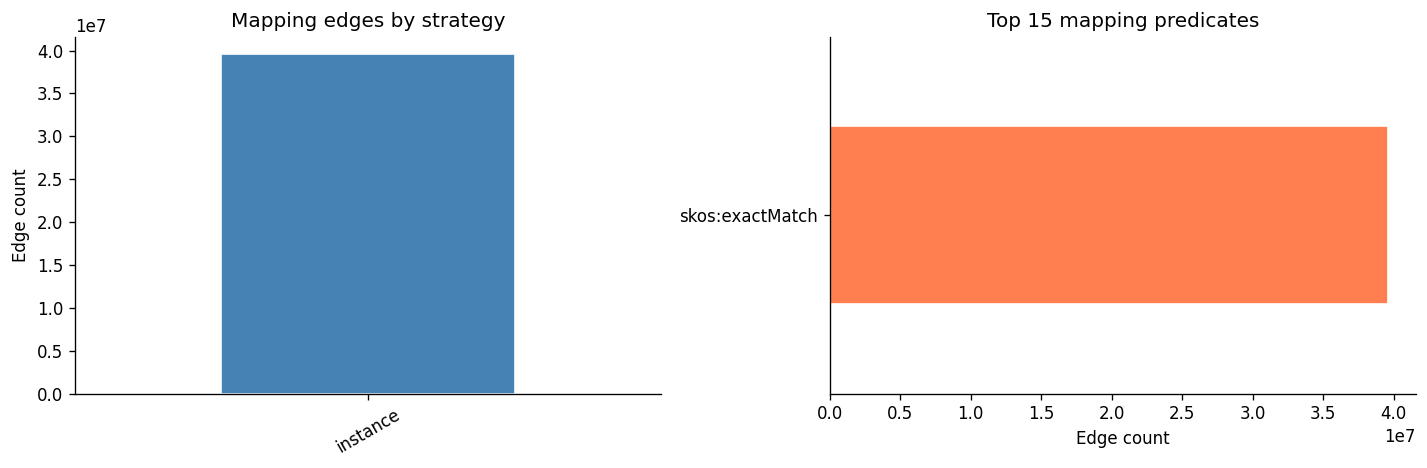

In [9]:
try:
    import ujson as _json
except ModuleNotFoundError:
    import json as _json

_SKIP_KEYS = frozenset({"void:inDataset", "dcterms:created"})

strategy_counts:  Counter = Counter()
predicate_counts: Counter = Counter()

mapping_dirs = {
    "sssom":      MAPPINGS_SSSOM,
    "semra":      MAPPINGS_SEMRA,
    "inferenced": MAPPINGS_INF,
}

for layer, directory in mapping_dirs.items():
    for mf in _safe_glob(directory):
        try:
            raw = _json.loads(mf.read_bytes())
            strategy = raw.get("@about", {}).get("strategy", "unknown")
            curie_map = raw.get("@about", {}).get("curie_map") or {}
            ctx = {**curie_map, **raw.get("@context", {})}
            for node in raw.get("@graph", ()):
                for key in node:
                    if key[0] == "@" or key in _SKIP_KEYS:
                        continue
                    val = node[key]
                    targets = val if isinstance(val, list) else (val,)
                    n = sum(1 for t in targets if isinstance(t, dict) and t.get("@id"))
                    strategy_counts[strategy] += n
                    predicate_counts[key] += n
        except Exception:
            pass

if strategy_counts:
    def _shorten_pred(uri: str) -> str:
        for sep in ("#", "/"):
            idx = uri.rfind(sep)
            if idx >= 0 and idx < len(uri) - 1:
                return uri[idx + 1:]
        return uri

    strat_series = pd.Series(strategy_counts).sort_values(ascending=False)
    print("Edges per strategy:")
    print(strat_series.to_string())
    print()

    pred_short = Counter({_shorten_pred(k): v for k, v in predicate_counts.items()})
    pred_series = pd.Series(pred_short).sort_values(ascending=False)
    print(f"Distinct predicates: {len(pred_series)}")
    print(pred_series.head(20).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    strat_series.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title("Mapping edges by strategy")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Edge count")
    axes[0].tick_params(axis="x", rotation=30)

    pred_series.head(15).plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
    axes[1].set_title("Top 15 mapping predicates")
    axes[1].set_xlabel("Edge count")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("No mapping edges loaded - check mapping directories.")

## 7. Graph construction

Three graph variants are built at the **dataset level** (nodes = datasets we mined a
schema for; edges = at least one class-to-class bridging connection).
Edge weights count the number of distinct class-pair bridges between each pair.

* **G_schema** - baseline: cross-dataset typed-object edges from mined schemas alone.
  An edge (A, B) exists when dataset A's schema references a class URI that dataset B
  also instantiates as a subject class.  This is the smallest graph.
* **G_raw** - G_schema augmented with curated mapping edges (sssom + semra).
  Only edges whose *both* endpoint datasets appear in G_schema are added.
* **G_inferred** - G_raw augmented with inferenced mapping edges (inversion,
  transitivity).  Same node-filter applies.

A fourth, commented-out variant **G_owl** would propagate predicates via subclass /
equivalence reasoning before computing cross-dataset reachability - see the commented
block below.

In [10]:
# G_schema, G_raw, and G_inferred were all built during the streaming pass in
# the previous cell.  Nothing to do here except confirm the node counts.
print(f"G_schema - nodes: {G_schema.number_of_nodes():3d}  edges: {G_schema.number_of_edges():5d}")
print(f"G_raw    - nodes: {G_raw.number_of_nodes():3d}  edges: {G_raw.number_of_edges():5d}")
print(f"G_inferred- nodes: {G_inferred.number_of_nodes():3d}  edges: {G_inferred.number_of_edges():5d}")

# ─────────────────────────────────────────────────────────────────────────────
# [FUTURE WORK] G_owl - OWL-reasoned predicate propagation layer
#
# If class C is related to C' via subClassOf / equivalentClass / skos:exactMatch
# the cross-dataset reachability of the schema graph can be expanded.
# Left for future work: requires materialised subClassOf in inference.py.
# ─────────────────────────────────────────────────────────────────────────────


G_schema - nodes: 105  edges:   554
G_raw    - nodes: 105  edges:   554
G_inferred- nodes: 105  edges:   554


## 8. Connectivity metrics

For each graph variant: number of edges, connected components, largest component size,
diameter (on the largest component), and density.

In [11]:
def graph_metrics(G: nx.Graph, label: str) -> dict:
    n = G.number_of_nodes()
    e = G.number_of_edges()
    components = list(nx.connected_components(G))
    n_comp = len(components)
    lcc = max(components, key=len)
    lcc_size = len(lcc)
    # Diameter of the largest connected component
    lcc_subgraph = G.subgraph(lcc)
    diameter = nx.diameter(lcc_subgraph) if lcc_size > 1 else 0
    density = nx.density(G)
    return {
        "graph":       label,
        "nodes":       n,
        "edges":       e,
        "components":  n_comp,
        "lcc_nodes":   lcc_size,
        "diameter":    diameter,
        "density":     round(density, 4),
    }


rows = [
    graph_metrics(G_schema,   "G_schema"),
    graph_metrics(G_raw,      "G_raw"),
    graph_metrics(G_inferred, "G_inferred"),
]
df_metrics = pd.DataFrame(rows).set_index("graph")
print(df_metrics.to_string())
df_metrics

            nodes  edges  components  lcc_nodes  diameter  density
graph                                                             
G_schema      105    554          33         73         5   0.1015
G_raw         105    554          33         73         5   0.1015
G_inferred    105    554          33         73         5   0.1015


,nodes,edges,components,lcc_nodes,diameter,density
graph,,,,,,
G_schema,105,554,33,73,5,0.1015
G_raw,105,554,33,73,5,0.1015
G_inferred,105,554,33,73,5,0.1015


## 9. Hidden bridges

Edges present in G_inferred but absent in G_raw represent dataset pairs that can only be
joined via inferred (transitive / inverse) mappings - connections invisible to analysis
based on curated mappings alone.

In [12]:
raw_edge_set      = set(frozenset(e) for e in G_raw.edges())
inferred_edge_set = set(frozenset(e) for e in G_inferred.edges())
new_bridges       = inferred_edge_set - raw_edge_set

print(f"Edges in G_inferred not in G_raw (hidden bridges): {len(new_bridges)}")
if new_bridges:
    bridge_rows = []
    for fs in sorted(new_bridges):
        u, v = tuple(fs)
        w = G_inferred[u][v]["weight"]
        bridge_rows.append({"dataset_A": u, "dataset_B": v, "inferred_pairs": w})
    df_bridges = (
        pd.DataFrame(bridge_rows)
        .sort_values("inferred_pairs", ascending=False)
        .reset_index(drop=True)
    )
    print(df_bridges.to_string(index=False))
    df_bridges.head(20)
else:
    print("No new bridges introduced by inference over the current mapping set.")

Edges in G_inferred not in G_raw (hidden bridges): 0
No new bridges introduced by inference over the current mapping set.


## 10. Hub ontology analysis

Classes that appear most often as bridging nodes (in both source and target position across
mapping edges) act as integration hubs.  Betweenness centrality on the dataset graph
identifies which datasets occupy structurally critical positions.

In [13]:
# ── Betweenness centrality on G_inferred ─────────────────────────────────────
bc     = nx.betweenness_centrality(G_inferred, weight="weight", normalized=True)
degree = dict(G_inferred.degree(weight="weight"))

df_centrality = (
    pd.DataFrame({"dataset": list(bc.keys()), "betweenness": list(bc.values())})
    .assign(degree=lambda d: d["dataset"].map(degree))
    .sort_values("betweenness", ascending=False)
    .reset_index(drop=True)
)
print("Top 20 datasets by betweenness centrality (G_inferred):")
print(df_centrality.head(20).to_string(index=False))

# ── Top bridging class URIs ───────────────────────────────────────────────────
# Derived from class_to_datasets: classes shared across the most datasets
# are the best structural hubs (schema-level proxy for bridge participation).
class_bridge_counts = Counter(
    {cls: len(ds) for cls, ds in class_to_datasets.items() if len(ds) > 1}
)
if class_bridge_counts:
    print(f"\nTop 20 classes spanning multiple datasets (schema-level hubs):")
    for cls, cnt in class_bridge_counts.most_common(20):
        print(f"  {cnt:3d} datasets  {_shorten(cls)}")


Top 20 datasets by betweenness centrality (G_inferred):
             dataset  betweenness  degree
             pubchem     0.178958     103
        wikipathways     0.167289    1307
         cellosaurus     0.107730     309
              chembl     0.081965   18170
   rdfportal.pubchem     0.066452      62
       rdfportal.pdb     0.065716     241
             uniprot     0.051718     882
                isdb     0.033607   17956
wikidata.idsm.entity     0.021098    3572
              gtopdb     0.018204      87
               chebi     0.017177    4139
      bio2rdf.chembl     0.013646   15417
          aopwikirdf     0.013256   13791
                mona     0.013256   83435
            metanetx     0.013256     107
                 ndc     0.002434     164
                 mgi     0.002434     164
                 goa     0.002434     164
                hgnc     0.002434     164
                mesh     0.002434     164

Top 20 classes spanning multiple datasets (schema-level hubs)

## 11. Domain annotation

Each dataset is assigned a **primary domain** derived from its `bioregistry_keywords`
in `sources.yaml`.  Keywords are ranked by specificity (least frequent across all
sources = most discriminating) and the top keyword is mapped to a coarse domain
category for colouring.

This is purely descriptive — no null-model assumptions, no modularity optimisation.
The graph structure is an engineered semantic dependency network, not a random graph.

In [57]:
# ── Coarse domain mapping ─────────────────────────────────────────────────────
# Map fine-grained bioregistry keywords to broad domain categories for colouring.
# A keyword not in this table keeps its original value; the first match wins.
DOMAIN_MAP = {
    # Chemistry / metabolomics
    "chemical":            "Chemistry",
    "chemical compound":   "Chemistry",
    "chemical structure":  "Chemistry",
    "metabolite":          "Chemistry",
    "compound":            "Chemistry",
    "mass spectrometry":   "Chemistry",
    "natural product":     "Chemistry",
    "organic chemistry":   "Chemistry",
    "nanomaterial":        "Chemistry",
    # Drug / pharmacology
    "drug":                "Pharmacology",
    "pharmacology":        "Pharmacology",
    "side effect":         "Pharmacology",
    "receptor":            "Pharmacology",
    # Protein / proteomics
    "protein":             "Protein",
    "proteomics":          "Protein",
    "kinase":              "Protein",
    "orthology":           "Protein",
    "3d structure":        "Protein",
    # Gene / genomics
    "gene":                "Genomics",
    "genome":              "Genomics",
    "gene expression":     "Genomics",
    "co-expression":       "Genomics",
    "sequence":            "Genomics",
    "dna":                 "Genomics",
    "rna":                 "Genomics",
    "regulation":          "Genomics",
    "microarray":          "Genomics",
    # Pathways / systems biology
    "interaction/pathway": "Pathways",
    "pathway":             "Pathways",
    "biopax":              "Pathways",
    "systems biology":     "Pathways",
    "reaction":            "Pathways",
    # Disease / phenotype
    "health/disease":      "Disease",
    "phenotype":           "Disease",
    "rare disease":        "Disease",
    "disease":             "Disease",
    # Toxicology
    "toxicology":          "Toxicology",
    "adverse outcome pathway": "Toxicology",
    # Ontology / terminology
    "ontology":            "Ontology",
    "ontology/terminology/nomenclature": "Ontology",
    "obo":                 "Ontology",
    # Ecology / environment
    "ecology":             "Environment",
    "biodiversity":        "Environment",
    "environment":         "Environment",
    "hydrology":           "Environment",
    "geospatial":          "Environment",
    "climate":             "Environment",
    "earth science":       "Environment",
    "agriculture":         "Environment",
    "soil":                "Environment",
    # Glycobiology
    "carbohydrate":        "Glycobiology",
    "glycomics":           "Glycobiology",
    # Microbiology
    "microbiology":        "Microbiology",
    "taxonomy":            "Taxonomy",
    # Immunology
    "immunology":          "Immunology",
    # Literature / bibliography
    "bibliography/documents": "Literature",
    "citation":            "Literature",
    "scholarly":           "Literature",
    # KG / integration
    "knowledge graph":     "Knowledge graph",
    "integration":         "Knowledge graph",
    "repository":          "Repository",
}

# ── Domain colour palette ─────────────────────────────────────────────────────
DOMAIN_COLOURS = {
    "Chemistry":       "#1f77b4",
    "Pharmacology":    "#ff7f0e",
    "Protein":         "#2ca02c",
    "Genomics":        "#d62728",
    "Pathways":        "#9467bd",
    "Disease":         "#8c564b",
    "Toxicology":      "#e377c2",
    "Ontology":        "#7f7f7f",
    "Environment":     "#bcbd22",
    "Glycobiology":    "#17becf",
    "Microbiology":    "#aec7e8",
    "Taxonomy":        "#ffbb78",
    "Immunology":      "#98df8a",
    "Literature":      "#ff9896",
    "Knowledge graph": "#c5b0d5",
    "Repository":      "#c49c94",
    "Bioactivities":   "#f7b6d2",
    "Enzyme":          "#dbdb8d",
    "Unknown":         "#cccccc",
}

# ── Compute keyword rarity across all sources for specificity ranking ─────────
kw_freq: Counter = Counter()
for kws in SOURCE_KEYWORDS.values():
    if kws:
        for kw in kws:
            kw_freq[kw] += 1

def _primary_domain(name: str) -> str:
    """Return the coarse domain for a source, picking its rarest keyword."""
    kws = SOURCE_KEYWORDS.get(name, [])
    if not kws:
        return "Unknown"
    # Sort by rarity (least frequent first) so the most specific keyword wins
    kws_sorted = sorted(kws, key=lambda k: kw_freq.get(k, 999))
    for kw in kws_sorted:
        if kw in DOMAIN_MAP:
            return DOMAIN_MAP[kw]
    # Fallback: first keyword's raw value
    return kws_sorted[0].capitalize()

# ── Assign domain to every graph node ─────────────────────────────────────────
node_domain: dict[str, str] = {}
for node in G_schema.nodes():
    node_domain[node] = _primary_domain(node)

domain_counts = Counter(node_domain.values())
print("Domain assignment (G_schema nodes):")
for dom, cnt in domain_counts.most_common():
    print(f"  {dom:<20s} {cnt:3d} datasets")
print(f"\nTotal: {sum(domain_counts.values())} nodes across {len(domain_counts)} domains")

Domain assignment (G_schema nodes):
  Chemistry             48 datasets
  Genomics              15 datasets
  Pathways               9 datasets
  Pharmacology           7 datasets
  Disease                5 datasets
  Protein                4 datasets
  Literature             3 datasets
  Unknown                2 datasets
  Toxicology             2 datasets
  Glycobiology           2 datasets
  Microbiology           1 datasets
  Enzyme                 1 datasets
  Cell/organelle         1 datasets
  Taxonomy               1 datasets
  Bioinformatics         1 datasets
  Environment            1 datasets
  Bioactivities          1 datasets
  Cell line              1 datasets

Total: 105 nodes across 18 domains


### Cross-domain connectivity

Which domain pairs are linked in the schema graph?  This counts edges between
domains (inter-domain) and within domains (intra-domain), showing the actual
integration structure without any clustering assumptions.

In [58]:
# ── Cross-domain edge statistics ──────────────────────────────────────────────
inter_domain_edges: Counter = Counter()  # (domA, domB) -> total weight
intra_domain_edges: Counter = Counter()  # domain -> total weight

for u, v, d in G_schema.edges(data=True):
    du = node_domain.get(u, "Unknown")
    dv = node_domain.get(v, "Unknown")
    w = d.get("weight", 1)
    if du == dv:
        intra_domain_edges[du] += w
    else:
        key = tuple(sorted([du, dv]))
        inter_domain_edges[key] += w

total_weight = sum(d.get("weight", 1) for _, _, d in G_schema.edges(data=True))
inter_weight = sum(inter_domain_edges.values())
intra_weight = sum(intra_domain_edges.values())

print(f"Total edge weight: {total_weight:,}")
print(f"  Intra-domain:    {intra_weight:,} ({100*intra_weight/total_weight:.1f}%)")
print(f"  Inter-domain:    {inter_weight:,} ({100*inter_weight/total_weight:.1f}%)")

print(f"\nTop 20 inter-domain connections (by total bridging weight):")
for (d1, d2), w in inter_domain_edges.most_common(20):
    print(f"  {d1:<20s} ↔ {d2:<20s}  weight={w:,}")

print(f"\nIntra-domain edge weight:")
for dom, w in intra_domain_edges.most_common():
    print(f"  {dom:<20s}  weight={w:,}")

Total edge weight: 91,272
  Intra-domain:    33,598 (36.8%)
  Inter-domain:    57,674 (63.2%)

Top 20 inter-domain connections (by total bridging weight):
  Chemistry            ↔ Pharmacology          weight=37,084
  Chemistry            ↔ Toxicology            weight=13,688
  Genomics             ↔ Glycobiology          weight=594
  Genomics             ↔ Pathways              weight=504
  Chemistry            ↔ Genomics              weight=406
  Genomics             ↔ Protein               weight=334
  Glycobiology         ↔ Pathways              weight=304
  Chemistry            ↔ Glycobiology          weight=290
  Glycobiology         ↔ Protein               weight=282
  Chemistry            ↔ Pathways              weight=272
  Pathways             ↔ Protein               weight=232
  Pathways             ↔ Pharmacology          weight=214
  Glycobiology         ↔ Pharmacology          weight=192
  Genomics             ↔ Literature            weight=190
  Genomics             ↔ Ph

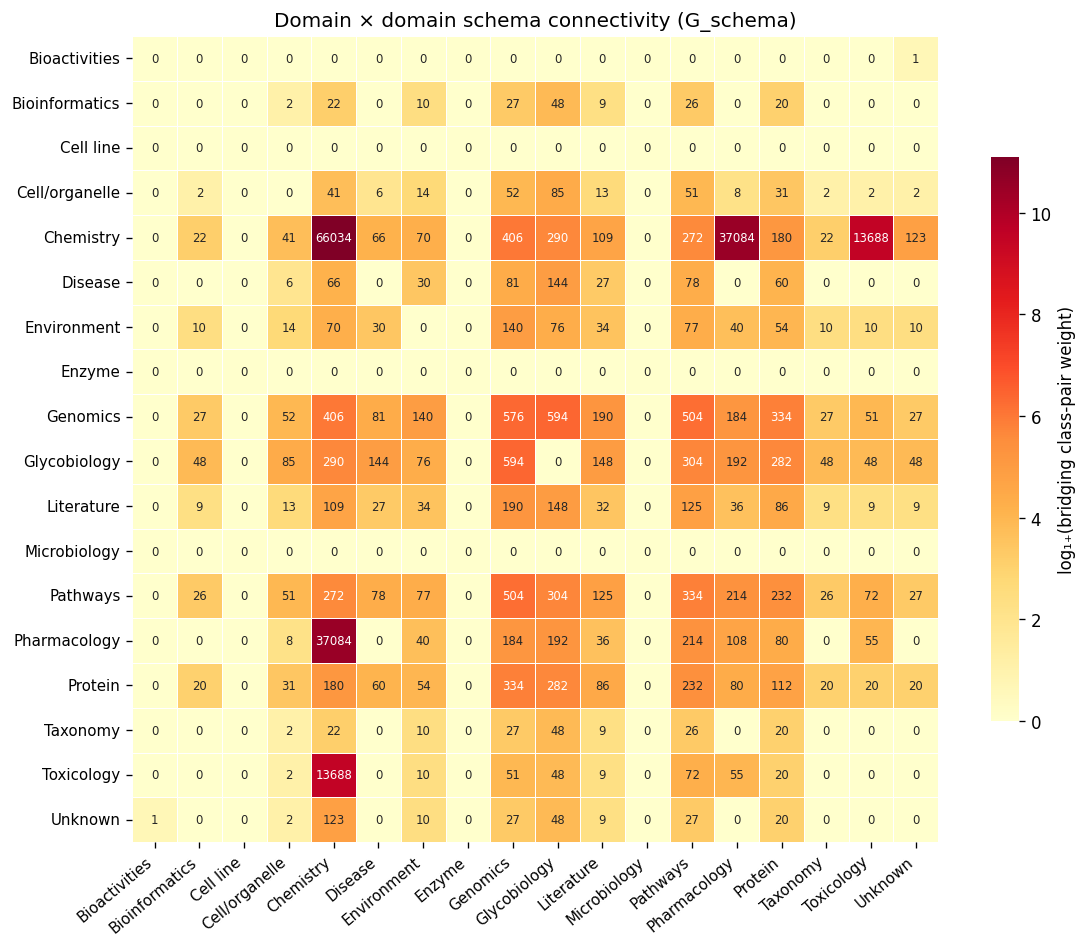

In [59]:
# ── Domain × domain adjacency heatmap ─────────────────────────────────────────
all_domains = sorted(domain_counts.keys())
dom_adj = pd.DataFrame(0, index=all_domains, columns=all_domains, dtype=float)

for u, v, d in G_schema.edges(data=True):
    du = node_domain.get(u, "Unknown")
    dv = node_domain.get(v, "Unknown")
    w = d.get("weight", 1)
    dom_adj.loc[du, dv] += w
    dom_adj.loc[dv, du] += w

dom_adj_log = np.log1p(dom_adj)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    dom_adj_log, ax=ax, cmap="YlOrRd", linewidths=0.5, linecolor="white",
    xticklabels=True, yticklabels=True, square=True,
    cbar_kws={"label": "log₁₊(bridging class-pair weight)", "shrink": 0.7},
    annot=dom_adj.astype(int), fmt="d", annot_kws={"fontsize": 7},
)
ax.set_title("Domain × domain schema connectivity (G_schema)", fontsize=12)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Network visualisation — radial domain layout

Datasets are arranged around a circle, **grouped by domain** with coloured arc
segments.  Node size reflects weighted degree.  Inter-domain edges are drawn as
quadratic Bézier curves routed through the centre (bundled); intra-domain edges
are short arcs along the periphery.  All dataset names are printed as radial labels.

In [1]:
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

# ── Work on the non-isolated subgraph ────────────────────────────────────────
G_viz = G_schema.copy()
G_viz.remove_nodes_from(list(nx.isolates(G_viz)))
n_nodes = G_viz.number_of_nodes()

# ── Sort domains by size (largest first) so biggest arcs are at top ──────────
dom_groups: dict[str, list[str]] = {}
for n in G_viz.nodes():
    d = node_domain.get(n, "Unknown")
    dom_groups.setdefault(d, []).append(n)

# Sort datasets within each domain by weighted degree (highest first)
node_strength = {n: G_viz.degree(n, weight="weight") for n in G_viz.nodes()}
for d in dom_groups:
    dom_groups[d].sort(key=lambda n: -node_strength[n])

# Order domains: largest first
dom_order = sorted(dom_groups.keys(), key=lambda d: -len(dom_groups[d]))

# ── Place nodes around a circle with small gaps between domains ──────────────
GAP_DEG = 3.0  # gap in degrees between domain arcs
n_domains = len(dom_order)
total_gap = GAP_DEG * n_domains
avail_deg = 360.0 - total_gap

# Each domain gets an arc proportional to its node count
pos: dict[str, np.ndarray] = {}
node_angles: dict[str, float] = {}  # degrees, for label rotation
domain_arc_mid: dict[str, float] = {}  # midpoint angle per domain

RADIUS = 10.0
cursor = 90.0  # start at top

for dom in dom_order:
    nodes = dom_groups[dom]
    arc_deg = avail_deg * len(nodes) / n_nodes
    # Distribute nodes evenly within this arc
    if len(nodes) == 1:
        angles = [cursor + arc_deg / 2]
    else:
        angles = np.linspace(cursor, cursor + arc_deg, len(nodes), endpoint=True).tolist()
    domain_arc_mid[dom] = cursor + arc_deg / 2
    for node, ang in zip(nodes, angles):
        rad = np.deg2rad(ang)
        pos[node] = np.array([RADIUS * np.cos(rad), RADIUS * np.sin(rad)])
        node_angles[node] = ang
    cursor += arc_deg + GAP_DEG

# ── Node aesthetics ──────────────────────────────────────────────────────────
max_strength = max(node_strength.values()) if node_strength else 1
node_list = list(G_viz.nodes())
node_colors = [DOMAIN_COLOURS.get(node_domain.get(n, "Unknown"), "#ccc") for n in node_list]
node_sizes = [20 + 180 * (node_strength[n] / max_strength) for n in node_list]

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

# 1) Inter-domain edges — Bézier curves through centre
for u, v, d in G_viz.edges(data=True):
    du, dv = node_domain.get(u, "Unknown"), node_domain.get(v, "Unknown")
    if du == dv:
        continue
    w = d.get("weight", 1)
    lw = 0.15 + 0.5 * np.log1p(w)
    p0 = pos[u]
    p2 = pos[v]
    ctrl = np.array([0.0, 0.0])  # route through centre
    verts = [p0, ctrl, p2]
    codes = [MplPath.MOVETO, MplPath.CURVE3, MplPath.CURVE3]
    path = MplPath(verts, codes)
    patch = PathPatch(path, fill=False, edgecolor="#555555",
                      alpha=min(0.04 + 0.03 * np.log1p(w), 0.25),
                      linewidth=lw)
    ax.add_patch(patch)

# 2) Intra-domain edges — straight lines along periphery (short)
for u, v, d in G_viz.edges(data=True):
    du, dv = node_domain.get(u, "Unknown"), node_domain.get(v, "Unknown")
    if du != dv:
        continue
    w = d.get("weight", 1)
    lw = 0.2 + 0.3 * np.log1p(w)
    colour = DOMAIN_COLOURS.get(du, "#ccc")
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color=colour, alpha=0.12, linewidth=lw)

# 3) Nodes
for i, n in enumerate(node_list):
    ax.scatter(pos[n][0], pos[n][1], s=node_sizes[i], c=node_colors[i],
               edgecolors="white", linewidths=0.4, alpha=0.9, zorder=5)

# 4) Radial labels — every dataset, rotated to follow the circle
LABEL_OFFSET = 0.6
for n in node_list:
    ang = node_angles[n]
    rad = np.deg2rad(ang)
    lx = (RADIUS + LABEL_OFFSET) * np.cos(rad)
    ly = (RADIUS + LABEL_OFFSET) * np.sin(rad)
    # Rotate label to be readable
    rot = ang
    ha = "left"
    if 90 < ang % 360 < 270:
        rot += 180
        ha = "right"
    ax.text(lx, ly, n, fontsize=5.5, rotation=rot, rotation_mode="anchor",
            ha=ha, va="center", color="#222222")

# 5) Domain arc labels (outside the node ring)
ARC_LABEL_R = RADIUS + 5
for dom in dom_order:
    mid_ang = domain_arc_mid[dom]
    rad = np.deg2rad(mid_ang)
    lx = ARC_LABEL_R * np.cos(rad)
    ly = ARC_LABEL_R * np.sin(rad)
    rot = mid_ang
    ha = "center"
    if 90 < mid_ang % 360 < 270:
        rot += 180
    colour = DOMAIN_COLOURS.get(dom, "#ccc")
    ax.text(lx, ly, f"{dom} ({len(dom_groups[dom])})",
            fontsize=8, fontweight="bold",
            ha="center", va="center", color=colour,
            rotation=rot, rotation_mode="anchor")

# 6) Legend
#legend_handles = [
#    mpatches.Patch(color=DOMAIN_COLOURS.get(d, "#ccc"), label=f"{d} ({len(dom_groups[d])})")
#    for d in dom_order
#]
#ax.legend(handles=legend_handles, loc="upper right", fontsize=7.5, framealpha=0.85,
#          title="Domain (datasets)", title_fontsize=9, ncol=3,)
#          #bbox_to_anchor=(0.5, 0.5))

#ax.set_title(
#    f"Schema dependency network",
#    fontsize=14, fontweight="bold", pad=20,
#)
ax.set_xlim(-RADIUS - 6, RADIUS + 6)
ax.set_ylim(-RADIUS - 6, RADIUS + 6)
ax.axis("off")
plt.tight_layout()
plt.show()

# ── Isolated datasets ────────────────────────────────────────────────────────
isolated = sorted(nx.isolates(G_schema))
if isolated:
    print(f"\nIsolated datasets ({len(isolated)}, no schema cross-references):")
    for n in isolated:
        print(f"  {n:<35s}  domain={node_domain.get(n, 'Unknown')}")

NameError: name 'G_schema' is not defined

## 13. Dataset × dataset reachability matrix

For G_schema, G_raw, and G_inferred: which dataset pairs are in the same connected
component?  The difference matrices show new connections introduced by each mapping layer.

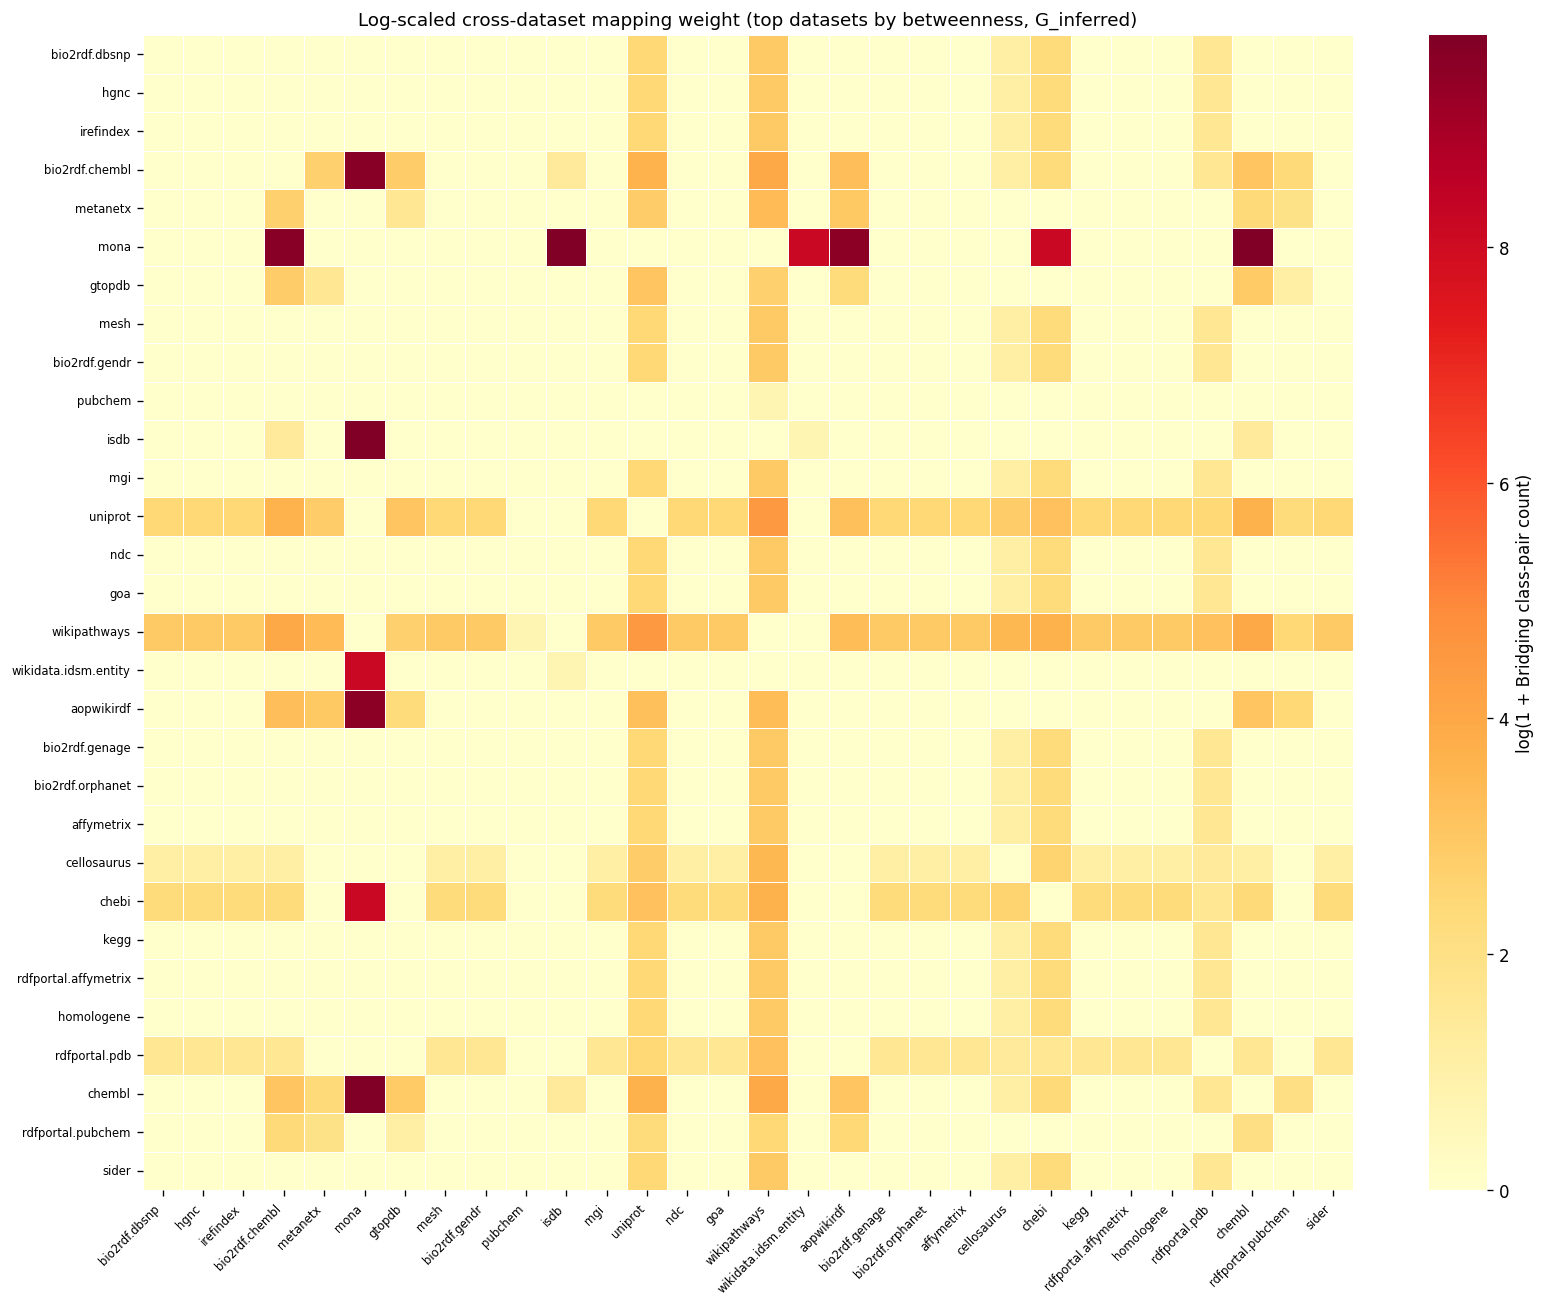

In [61]:
# Log-scaled heatmap of the edge-weight matrix for G_inferred (top-N datasets)
top_ds = df_centrality.head(min(30, len(df_centrality)))["dataset"].tolist()

if len(top_ds) > 1:
    adj = nx.to_pandas_adjacency(G_inferred.subgraph(top_ds), weight="weight").astype(float)
    adj_log = np.log1p(adj)  # log(1 + x) to handle zeros safely

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        adj_log, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white",
        xticklabels=True, yticklabels=True,
        cbar_kws={"label": "log(1 + Bridging class-pair count)"},
    )
    ax.set_title("Log-scaled cross-dataset mapping weight (top datasets by betweenness, G_inferred)", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()


## 14. Schema structural profile

- Distribution of pattern counts and class counts across the 90 mined schemas;
- Top predicates observed within schema typed-object patterns.

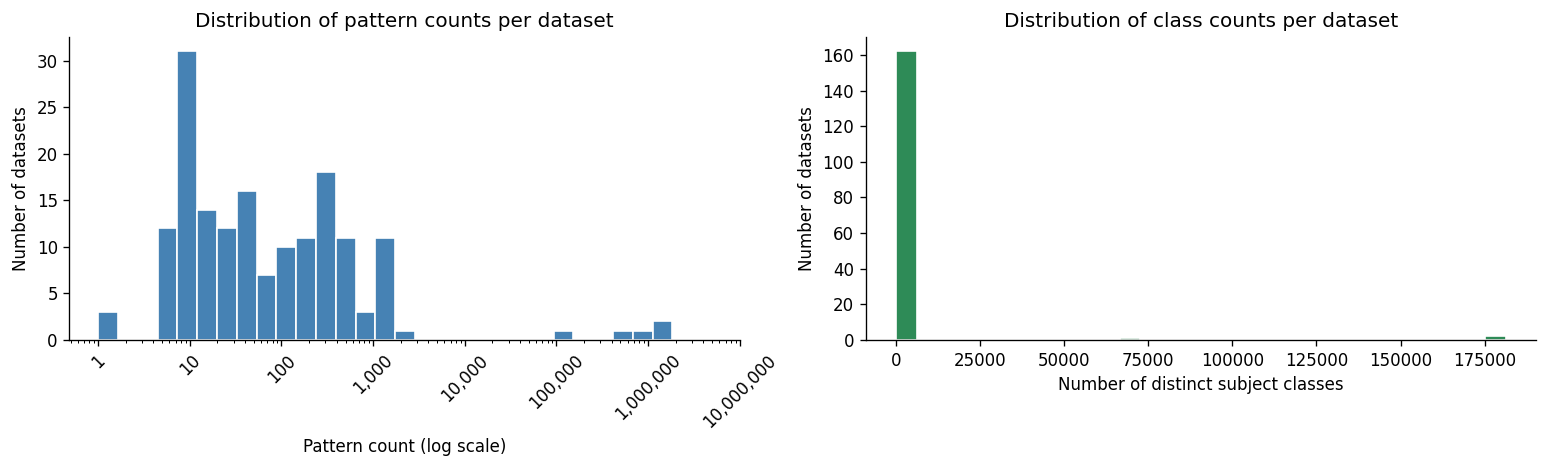

Largest schemas by pattern count:
            dataset  pattern_count  class_count  to_patterns  lit_patterns               strategy
  pubchem.substance        1845855       181224            0        543672 miner/two-phase+counts
  pubchem.substance        1845855       181224            0        543672 miner/two-phase+counts
pubchem.ftp.protein         851749        69767        25981        269408 miner/two-phase+counts
    lifesciencedict         556088            3            6             4 miner/two-phase+counts
               mona          99015         3618        88198            40 miner/two-phase+counts
          irefindex           2305            3            0             3 miner/two-phase+counts
                sgd           1485           31            0            46 miner/two-phase+counts
           drugbank           1438            3            0             3 miner/two-phase+counts
       wikipathways           1429           27           73           177 miner/two

In [62]:
schema_stats = []
for ms in schemas:
    schema_stats.append({
        "dataset":       ms.about.dataset_name or ms.about.endpoint or "unknown",
        "pattern_count": ms.about.pattern_count or len(ms.patterns),
        "class_count":   len({p.subject_class for p in ms.patterns}),
        "to_patterns":   sum(1 for p in ms.patterns if p.object_class not in ("Literal", "Resource")),
        "lit_patterns":  sum(1 for p in ms.patterns if p.object_class == "Literal"),
        "strategy":      ms.about.strategy,
    })

df_schema_stats = pd.DataFrame(schema_stats).sort_values("pattern_count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# X-axis on log scale: use log-spaced bins and set xscale to 'log'
pattern_counts = df_schema_stats["pattern_count"].clip(lower=1)  # avoid zeros for log scale
log_bins = np.logspace(np.log10(pattern_counts.min()), np.log10(pattern_counts.max()), 30)

axes[0].hist(
    pattern_counts,
    bins=log_bins, color="steelblue", edgecolor="white",
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution of pattern counts per dataset")
axes[0].set_xlabel("Pattern count (log scale)")
axes[0].set_ylabel("Number of datasets")
# nicer x ticks at powers of 10, but show plain numeric labels
logmin = int(np.floor(np.log10(pattern_counts.min())))
logmax = int(np.ceil(np.log10(pattern_counts.max())))
xticks = [10 ** i for i in range(logmin, logmax + 1)]
axes[0].set_xticks(xticks)

import matplotlib.ticker as mticker
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f"{int(val):,}"))
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(
    df_schema_stats["class_count"],
    bins=30, color="seagreen", edgecolor="white", log=False,
)
axes[1].set_title("Distribution of class counts per dataset")
axes[1].set_xlabel("Number of distinct subject classes")
axes[1].set_ylabel("Number of datasets")

plt.tight_layout()
plt.show()

print("Largest schemas by pattern count:")
print(df_schema_stats.head(15).to_string(index=False))

print("Schema predicate frequency (from loaded patterns)")
schema_preds: Counter = Counter()
for ms in schemas:
    for pat in ms.patterns:
        if pat.object_class not in ("Literal", "Resource"):
            schema_preds[_shorten(pat.property_uri)] += 1

print(f"\nTop 20 predicates in schema typed-object patterns:")
for pred, cnt in schema_preds.most_common(20):
    print(f"  {cnt:8,d}  {pred}")

## 15. Summary

Key figures for the paper
- Mapping inventory and inference expansion,
- Cross-endpoint connectivity graph.

In [63]:
n_sssom = strategy_counts.get("sssom_import", 0)
n_semra = strategy_counts.get("semra_import", 0)
n_inf   = strategy_counts.get("inferenced", 0)

raw_edge_set      = set(frozenset(e) for e in G_raw.edges())
inferred_edge_set = set(frozenset(e) for e in G_inferred.edges())
schema_edge_set   = set(frozenset(e) for e in G_schema.edges())
new_pairs_raw = raw_edge_set - schema_edge_set
new_pairs_inf = inferred_edge_set - raw_edge_set

isolated = sorted(nx.isolates(G_schema))

summary = {
    "Mined schemas":                      len(schemas),
    "Total typed-object schema patterns": len(df_sch),
    "Total schema patterns (all types)":  len(df_schema),
    "SSSOM mapping edges":                n_sssom,
    "SeMRA mapping edges":                n_semra,
    "Inferenced mapping edges":           n_inf,
    "G_schema nodes / edges":             f"{G_schema.number_of_nodes()} / {G_schema.number_of_edges()}",
    "G_raw nodes / edges":                f"{G_raw.number_of_nodes()} / {G_raw.number_of_edges()}",
    "G_inferred nodes / edges":           f"{G_inferred.number_of_nodes()} / {G_inferred.number_of_edges()}",
    "G_schema components":                df_metrics.loc["G_schema",   "components"],
    "G_raw components":                   df_metrics.loc["G_raw",      "components"],
    "G_inferred components":              df_metrics.loc["G_inferred", "components"],
    "New dataset pairs (raw maps)":       len(new_pairs_raw),
    "New dataset pairs (inference)":      len(new_pairs_inf),
    "Domain categories":                  len(domain_counts),
    "Isolated datasets":                  len(isolated),
}

for k, v in summary.items():
    print(f"  {k:<45s}: {v}")

  Mined schemas                                : 165
  Total typed-object schema patterns           : 115302
  Total schema patterns (all types)            : 3145743
  SSSOM mapping edges                          : 0
  SeMRA mapping edges                          : 0
  Inferenced mapping edges                     : 0
  G_schema nodes / edges                       : 105 / 554
  G_raw nodes / edges                          : 105 / 554
  G_inferred nodes / edges                     : 105 / 554
  G_schema components                          : 33
  G_raw components                             : 33
  G_inferred components                        : 33
  New dataset pairs (raw maps)                 : 0
  New dataset pairs (inference)                : 0
  Domain categories                            : 18
  Isolated datasets                            : 32
